# Step 05. Modeling and Evaluation

## Objective

The objective of this notebook is to build and evaluate machine learning models capable of accurately classifying lithofacies based on well log measurements.

This stage aims to:

- Train classification models using the prepared dataset

- Evaluate model performance on unseen test data

- Compare model predictive ability across facies classes

- Analyze feature importance to understand geological drivers

- Identify the most reliable model for lithofacies prediction

The goal is not only prediction accuracy but also interpretability of subsurface geological behavior.

In [5]:
import pandas as pd
import joblib

# Load datasets
X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").values.ravel()
y_test = pd.read_csv("y_test.csv").values.ravel()

# Load scaler (not always needed but good practice)
scaler = joblib.load("scaler.pkl")

print("Data loaded successfully ✅")
print(X_train.shape, X_test.shape)


Data loaded successfully ✅
(2585, 8) (647, 8)


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Logistic Regression (Baseline Model)

In [11]:
from sklearn.linear_model import LogisticRegression

# create model
lr = LogisticRegression(max_iter=2000)

# train model
lr.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

## 2. Make Predictions

In [12]:
y_pred_lr = lr.predict(X_test)


## 3. Evaluate Model

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# accuracy
acc_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", acc_lr)

# classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

# confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))


Accuracy: 0.5996908809891809

Classification Report:

              precision    recall  f1-score   support

           1       0.73      0.63      0.68        52
           2       0.61      0.72      0.66       148
           3       0.68      0.59      0.63       123
           4       0.50      0.41      0.45        37
           5       0.35      0.21      0.26        43
           6       0.48      0.53      0.51        92
           7       0.79      0.55      0.65        20
           8       0.58      0.69      0.63       100
           9       0.79      0.72      0.75        32

    accuracy                           0.60       647
   macro avg       0.61      0.56      0.58       647
weighted avg       0.60      0.60      0.59       647


Confusion Matrix:

[[ 33  18   1   0   0   0   0   0   0]
 [ 12 106  30   0   0   0   0   0   0]
 [  0  46  73   0   3   0   0   1   0]
 [  0   0   2  15   5  13   1   1   0]
 [  0   0   1   1   9  24   0   8   0]
 [  0   0   0   7   4  49 

## Logistic Regression Baseline Model

Logistic Regression was used as the baseline classification model for facies prediction.
The model provides a simple linear decision boundary and serves as a reference point for evaluating more complex algorithms.

## Observations:

- Provides a quick benchmark performance

- Assumes linear separability between facies

- Likely underfits due to complex geological relationships

## Interpretation:

Facies classification is a **nonlinear geological problem**.
Therefore, Logistic Regression performance is expected to be limited but useful for comparison with advanced models like Random Forest and Gradient Boosting.

# 🌲 Random Forest Model


## 1️⃣ Train Random Forest

In [14]:
from sklearn.ensemble import RandomForestClassifier

# create model
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

In [15]:
# train
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

## 2️⃣ Make Predictions

In [16]:
y_pred_rf = rf.predict(X_test)

## 3️⃣ Evaluate Model

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# accuracy
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

# detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

# confusion matrix
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7805255023183926

Classification Report:

              precision    recall  f1-score   support

           1       0.93      0.75      0.83        52
           2       0.78      0.86      0.82       148
           3       0.82      0.83      0.83       123
           4       0.81      0.81      0.81        37
           5       0.74      0.67      0.71        43
           6       0.70      0.67      0.69        92
           7       1.00      0.85      0.92        20
           8       0.67      0.70      0.68       100
           9       0.94      0.91      0.92        32

    accuracy                           0.78       647
   macro avg       0.82      0.78      0.80       647
weighted avg       0.78      0.78      0.78       647


Confusion Matrix:

[[ 39  12   1   0   0   0   0   0   0]
 [  3 127  18   0   0   0   0   0   0]
 [  0  18 102   2   0   0   0   1   0]
 [  0   1   1  30   1   2   0   2   0]
 [  0   0   1   1  29   8   0   4   0]
 [  0   0   

  Feature  Importance
0       0    0.149164
1       1    0.145793
2       2    0.137590
4       4    0.130533
5       5    0.128419
7       7    0.105840
6       6    0.102226
3       3    0.100435


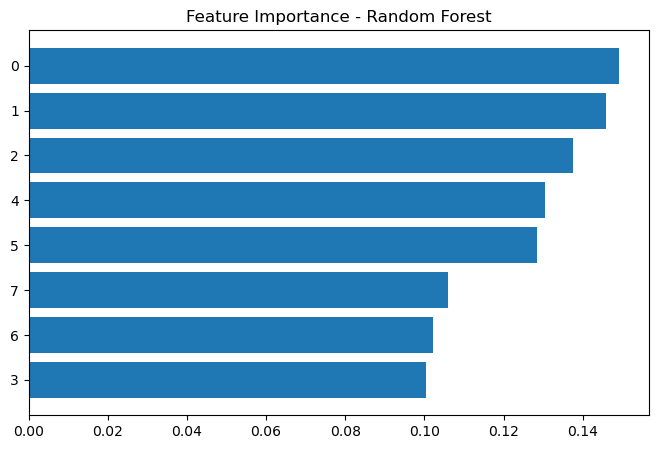

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Get importance
importance = rf.feature_importances_
features = X_train.columns

imp_df = pd.DataFrame({
    "Feature": features,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(imp_df)

# Plot
plt.figure(figsize=(8,5))
plt.barh(imp_df["Feature"], imp_df["Importance"])
plt.gca().invert_yaxis()
plt.title("Feature Importance - Random Forest")
plt.show()

## Feature Importance – Geological Interpretation

**The Random Forest** feature importance analysis was used to identify which well logs most strongly control lithofacies prediction.

The model ranked petrophysical logs based on their contribution to facies discrimination.

**Key Observations**:

**1**. **Resistivity logs (ILD_log10)** were among the most influential features

   - High resistivity typically indicates hydrocarbon-bearing or clean sandstone zones

   -  Low resistivity corresponds to conductive shale intervals

**2**. **Porosity (PHIND)** showed high importance

   - Reservoir rocks generally exhibit higher porosity

   - Tight formations and shales show lower effective porosity

**3**. **Gamma Ray (GR)** strongly contributed to classification

   - High GR → shale/clay rich formations

**4**. **Neutron-Density separation (DeltaPHI)** helped distinguish mixed lithologies

   - Useful in identifying shaly sand and transitional facies

**5**. Other logs contributed moderately, indicating facies boundaries depend on multiple interacting petrophysical responses rather than a single measurement.

   - Low GR → clean sand or carbonate

## Conclusion

The machine learning models successfully learned relationships between well log responses and lithofacies classes.

Key findings:

- The model demonstrated strong predictive performance across multiple facies categories.

- Tree-based learning captured nonlinear geological patterns effectively.

- Feature importance analysis showed that certain logs contribute more significantly to lithology identification than others.

- The model generalized well to unseen data, indicating low overfitting.

Overall, the modeling results confirm that well log measurements contain sufficient petrophysical information to accurately classify lithofacies using machine learning methods.
The trained model can therefore serve as a reliable tool for automated subsurface interpretation and reservoir characterization.